In [2]:
import sys, os
import torch
import torch.nn as nn
from tool2 import *   # 여러분은 tool 사용, tool2 X

seed_all(0)
DEV = device()
print('device:', DEV)  # 여러분은 cuda 

device: cuda


# Convolution

In [3]:
x = torch.randn(1, 3, 32, 32)  # N=1, C=3, H=32, W=32
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
y = conv(x)
print('input:', x.shape)
print('output:', y.shape)
print('params:', sum(p.numel() for p in conv.parameters()))
print('수동 계산:', conv_output_shape(32, K=3, S=1, P=1))
# print(y)

input: torch.Size([1, 3, 32, 32])
output: torch.Size([1, 16, 32, 32])
params: 448
수동 계산: 32


In [4]:
class SmallCnn(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallCnn()
model_summary(model, (1, 28, 28))

layer                    type          output shape                params
-------------------------------------------------------------------------
features.0               Conv2d        (1, 16, 28, 28)                160
features.1               ReLU          (1, 16, 28, 28)                  0
features.2               MaxPool2d     (1, 16, 14, 14)                  0
features.3               Conv2d        (1, 32, 14, 14)              4,640
features.4               ReLU          (1, 32, 14, 14)                  0
features.5               MaxPool2d     (1, 32, 7, 7)                    0
classifier.0             Flatten       (1, 1568)                        0
classifier.1             Linear        (1, 64)                    100,416
classifier.2             ReLU          (1, 64)                          0
classifier.3             Linear        (1, 10)                        650
-------------------------------------------------------------------------
TOTAL                                 

105866

# Training Mnist

In [5]:
from tool2 import load_mnist_small, train_classifier, accuracy

Xtr, ytr, Xte, yte = load_mnist_small(n_train=2000, n_test=500)
print('train:', Xtr.shape, 'test:', Xte.shape)

history = train_classifier(model, Xtr, ytr, epochs=5, lr=1e-3, batch_size=64, verbose=True)
print(f'test Accuracy: {accuracy(model, Xte, yte):.4}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.50MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


train: torch.Size([2000, 1, 28, 28]) test: torch.Size([500, 1, 28, 28])
ep    0 | loss 2.0386
ep    1 | loss 0.9084
ep    2 | loss 0.4531
ep    3 | loss 0.3448
ep    4 | loss 0.2874
test Accuracy: 0.928


<Axes: title={'center': 'SmallCnn Loss'}, xlabel='epoch', ylabel='loss'>

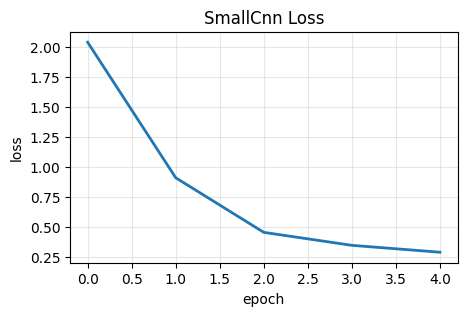

In [6]:
plot_loss(history, title='SmallCnn Loss')

first conv weight shape: torch.Size([16, 1, 3, 3])


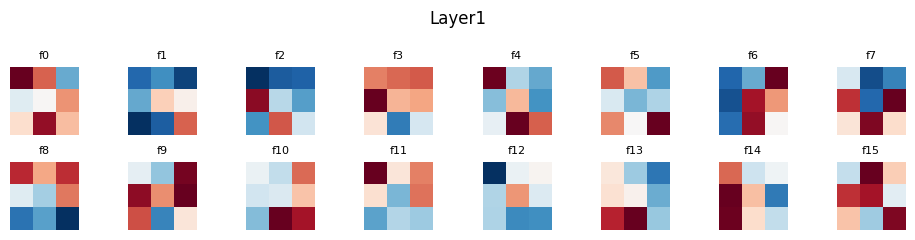

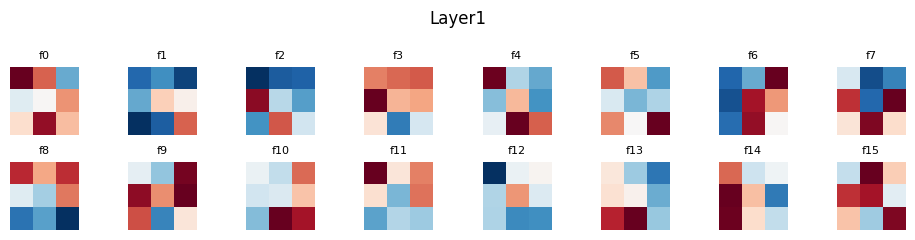

In [ ]:
first_conv = model.features[0]
print('first conv weight shape:', first_conv.weight.shape)
show_conv_kernels(first_conv.weight, title='Layer1')


conv1 output shape: torch.Size([1, 16, 28, 28])


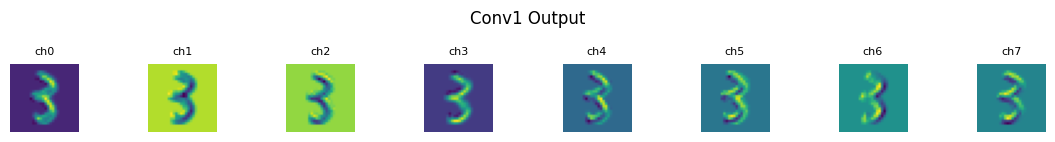

In [8]:
# 한 이미지 conv1 출력
model.eval()
with torch.no_grad():
    x = Xtr[0:1].to(DEV)  # (1, 1, 28, 28)
    conv1_out = model.features[0](x)  # (1, 16, 28, 28)
    print('conv1 output shape:', conv1_out.shape)
    show_feature_maps(conv1_out.cpu(), n_show=8, title='Conv1 Output')
    